In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

print("\nLoading DINOv2 ViT-S/14...")

model = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

model.eval()

print("\nDINOv2 loaded successfully!")
print("Model:", type(model))

PyTorch: 2.12.0+cpu
CUDA available: False

Loading DINOv2 ViT-S/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\Home/.cache\torch\hub\main.zip


C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to C:\Users\Home/.cache\torch\hub\checkpoints\dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [01:17<00:00, 1.14MB/s]



DINOv2 loaded successfully!
Model: <class 'dinov2.models.vision_transformer.DinoVisionTransformer'>


In [3]:
import torch
from PIL import Image
from torchvision import transforms

# --------------------------------------------------
# 1. Load DINOv2
# --------------------------------------------------
print("Loading DINOv2...")

model = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

model.eval()

# Freeze the model
for param in model.parameters():
    param.requires_grad = False

print("DINOv2 loaded.")


# --------------------------------------------------
# 2. Load BUSI image
# --------------------------------------------------
image_path = r"E:\Research Datasets\Unet segmentation work\Medical Foundation\Data\test2.bmp"

image = Image.open(image_path)

print("Original image:")
print("Format:", image.format)
print("Mode:", image.mode)
print("Size:", image.size)


# --------------------------------------------------
# 3. Convert image to RGB
# --------------------------------------------------
image = image.convert("RGB")


# --------------------------------------------------
# 4. DINOv2 preprocessing
# --------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

image_tensor = transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

print("\nInput tensor:")
print("Shape:", image_tensor.shape)


# --------------------------------------------------
# 5. Extract DINOv2 representation
# --------------------------------------------------
with torch.no_grad():
    features = model(image_tensor)

print("\nDINOv2 representation:")
print("Shape:", features.shape)
print("Feature vector size:", features.shape[-1])


# --------------------------------------------------
# 6. Basic statistics
# --------------------------------------------------
print("\nFeature statistics:")
print("Minimum:", features.min().item())
print("Maximum:", features.max().item())
print("Mean:", features.mean().item())
print("Std:", features.std().item())

Loading DINOv2...


Using cache found in C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 loaded.
Original image:
Format: BMP
Mode: L
Size: (427, 277)

Input tensor:
Shape: torch.Size([1, 3, 224, 224])

DINOv2 representation:
Shape: torch.Size([1, 384])
Feature vector size: 384

Feature statistics:
Minimum: -7.5192694664001465
Maximum: 7.4669084548950195
Mean: -0.004197047557681799
Std: 2.355354070663452


VISUALIZING LATENT SPACE 

In [4]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA

# BUSI image folder
image_dir = r"E:\Research Datasets\BUSI\train\img"

# Find BMP images
image_files = sorted([
    os.path.join(image_dir, f)
    for f in os.listdir(image_dir)
    if f.lower().endswith(".bmp")
])

print("Number of images found:", len(image_files))
print("First 10 images:")

for f in image_files[:10]:
    print(os.path.basename(f))

Number of images found: 555
First 10 images:
00001.bmp
00002.bmp
00003.bmp
00006.bmp
00011.bmp
00013.bmp
00014.bmp
00016.bmp
00020.bmp
00023.bmp


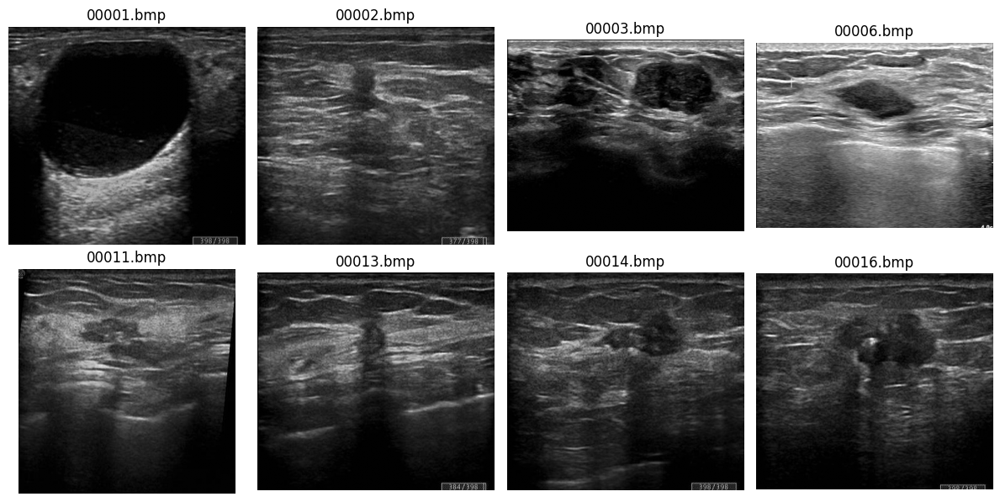

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image_path in zip(axes.flat, image_files[:8]):
    image = Image.open(image_path).convert("L")
    ax.imshow(image, cmap="gray")
    ax.set_title(os.path.basename(image_path))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print("Loading DINOv2...")

model = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

model.eval()

# Freeze DINOv2
for param in model.parameters():
    param.requires_grad = False

print("DINOv2 ready.")

Loading DINOv2...


Using cache found in C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 ready.


In [7]:
##Because BUSI is grayscale but DINOv2 expects 3-channel RGB input, we'll explicitly convert grayscale → RGB.

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [8]:
# Start small because we are running on CPU
max_images = 50

selected_files = image_files[:max_images]

features = []
filenames = []

print(f"Extracting DINOv2 features from {len(selected_files)} images...")

with torch.no_grad():

    for i, image_path in enumerate(selected_files):

        image = Image.open(image_path).convert("RGB")

        image_tensor = transform(image).unsqueeze(0)

        feature = model(image_tensor)

        features.append(feature.squeeze(0).numpy())
        filenames.append(os.path.basename(image_path))

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(selected_files)}")

features = np.array(features)

print("\nFinished!")
print("Feature matrix shape:", features.shape)

Extracting DINOv2 features from 50 images...
Processed 10/50
Processed 20/50
Processed 30/50
Processed 40/50
Processed 50/50

Finished!
Feature matrix shape: (50, 384)


In [ ]:
#ACTUAL REPRESENTATION VALUES CREATED BY DINO

print("Image:", filenames[0])
print("Representation shape:", features[0].shape)

print("\nFirst 20 feature values:")
print(features[0][:20])

Image: 00001.bmp
Representation shape: (384,)

First 20 feature values:
[-1.8649585  -0.9262074  -2.0329146   3.1683285  -3.7748427  -2.2013984
 -3.5088987  -5.6011105   2.7786508   0.0994269   0.686206    2.0760455
  1.425329    4.1739025   4.626612    2.5397305   1.8891935  -0.30818102
 -0.9007547   2.2604518 ]


In [10]:
#VISUALIZING REPRESENTATIONS THROUGH PCA, FIRST CONVERT 384D INTO 2D

pca = PCA(n_components=2)

features_2d = pca.fit_transform(features)

print("Original feature shape:", features.shape)
print("PCA shape:", features_2d.shape)

print("Variance explained by PC1:",
      pca.explained_variance_ratio_[0])

print("Variance explained by PC2:",
      pca.explained_variance_ratio_[1])

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Original feature shape: (50, 384)
PCA shape: (50, 2)
Variance explained by PC1: 0.2132884
Variance explained by PC2: 0.100655936
Total variance explained: 0.31394434


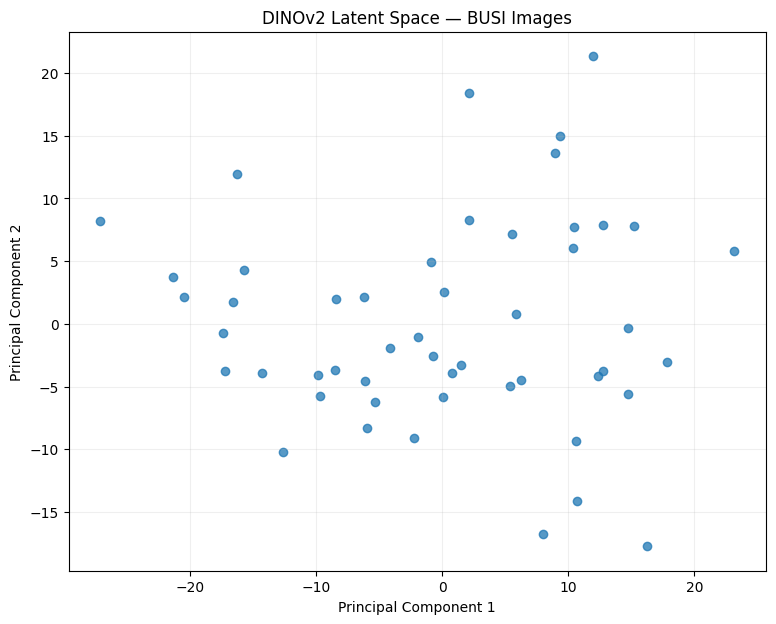

In [11]:
plt.figure(figsize=(9, 7))

plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DINOv2 Latent Space — BUSI Images")

plt.grid(alpha=0.2)
plt.show()

In [12]:
# Extract DINOv2 features from ALL 555 BUSI training images

selected_files = image_files

features = []
filenames = []

print(f"Extracting DINOv2 features from {len(selected_files)} images...")
print("This may take some time because DINOv2 is running on CPU.\n")

with torch.no_grad():

    for i, image_path in enumerate(selected_files):

        # Load BUSI grayscale image and convert to RGB
        image = Image.open(image_path).convert("RGB")

        # Apply DINOv2 preprocessing
        image_tensor = transform(image).unsqueeze(0)

        # Extract frozen DINOv2 representation
        feature = model(image_tensor)

        # Store the 384-dimensional representation
        features.append(feature.squeeze(0).numpy())
        filenames.append(os.path.basename(image_path))

        # Progress update
        if (i + 1) % 25 == 0 or (i + 1) == len(selected_files):
            print(f"Processed {i + 1}/{len(selected_files)}")

# Convert list → NumPy array
features = np.array(features)

print("\nFinished!")
print("Number of images:", len(filenames))
print("Feature matrix shape:", features.shape)

Extracting DINOv2 features from 555 images...
This may take some time because DINOv2 is running on CPU.

Processed 25/555
Processed 50/555
Processed 75/555
Processed 100/555
Processed 125/555
Processed 150/555
Processed 175/555
Processed 200/555
Processed 225/555
Processed 250/555
Processed 275/555
Processed 300/555
Processed 325/555
Processed 350/555
Processed 375/555
Processed 400/555
Processed 425/555
Processed 450/555
Processed 475/555
Processed 500/555
Processed 525/555
Processed 550/555
Processed 555/555

Finished!
Number of images: 555
Feature matrix shape: (555, 384)


In [13]:
# Save DINOv2 representations so we don't have to extract them again

save_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_features.npy"

np.save(save_path, features)

print("Features saved to:")
print(save_path)

Features saved to:
E:\Research Datasets\BUSI\busi_train_dinov2_features.npy


In [14]:
filename_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_filenames.npy"

np.save(filename_path, np.array(filenames))

print("Filenames saved to:")
print(filename_path)

Filenames saved to:
E:\Research Datasets\BUSI\busi_train_dinov2_filenames.npy


In [15]:
# PCA visualization of all 555 DINOv2 representations

pca = PCA(n_components=2)

features_2d = pca.fit_transform(features)

print("Original feature shape:", features.shape)
print("PCA shape:", features_2d.shape)

print("PC1 variance explained:",
      pca.explained_variance_ratio_[0])

print("PC2 variance explained:",
      pca.explained_variance_ratio_[1])

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Original feature shape: (555, 384)
PCA shape: (555, 2)
PC1 variance explained: 0.16741996
PC2 variance explained: 0.09422867
Total variance explained: 0.26164863


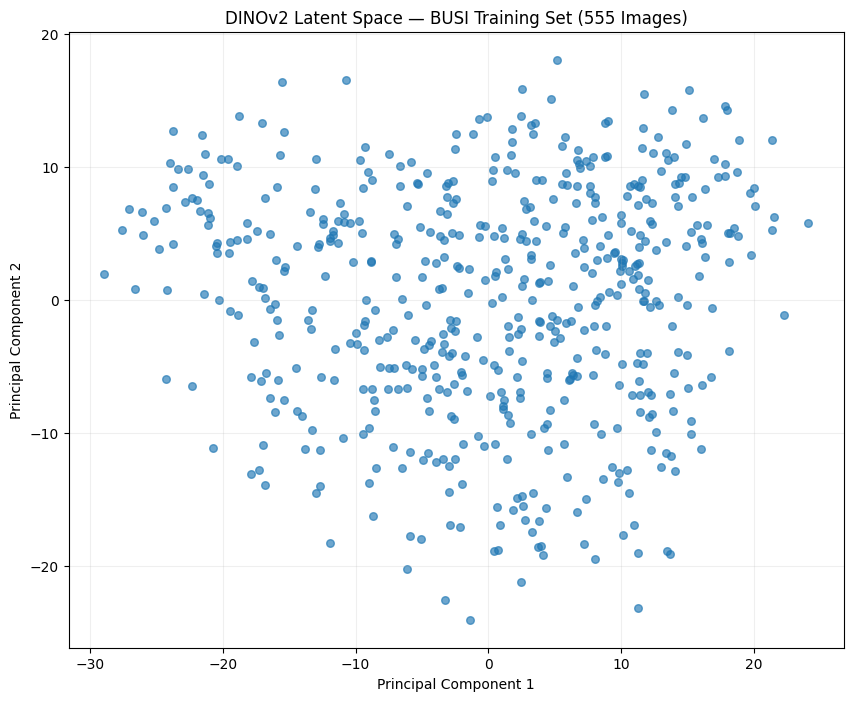

In [16]:
plt.figure(figsize=(10, 8))

plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    alpha=0.65,
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DINOv2 Latent Space — BUSI Training Set (555 Images)")

plt.grid(alpha=0.2)
plt.show()

The first two principal components of the DINOv2 embeddings explain 26.16% of the variance in the BUSI training-set representations, with no obvious separation in the 2D projection


TIll now we have seen dino global representation, but dino also creates patch level representations.. now we are moving towards patch level represenatation

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
CUDA: False


In [18]:
print(model)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1

In [19]:
# Take the first BUSI training image
test_image_path = image_files[0]

image = Image.open(test_image_path).convert("RGB")

print("Image:", os.path.basename(test_image_path))
print("Original size:", image.size)

# DINO preprocessing
image_tensor = transform(image).unsqueeze(0)

print("Input tensor:", image_tensor.shape)

Image: 00001.bmp
Original size: (442, 407)
Input tensor: torch.Size([1, 3, 224, 224])


In [20]:
with torch.no_grad():
    outputs = model.forward_features(image_tensor)

print(outputs.keys())

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


In [ ]:
patch_tokens = outputs["x_norm_patchtokens"]

print("Patch token shape:", patch_tokens.shape)
#1     = number of images
#256   = number of spatial patches
#384   = representation size of each patch

Patch token shape: torch.Size([1, 256, 384])


In [22]:
patch_strength = patch_tokens.norm(dim=-1).squeeze(0)

print("Patch strength shape:", patch_strength.shape)
print("Minimum:", patch_strength.min().item())
print("Maximum:", patch_strength.max().item())

Patch strength shape: torch.Size([256])
Minimum: 45.48560333251953
Maximum: 55.70441436767578


In [23]:
patch_map = patch_strength.reshape(16, 16)

print("Patch map shape:", patch_map.shape)

Patch map shape: torch.Size([16, 16])


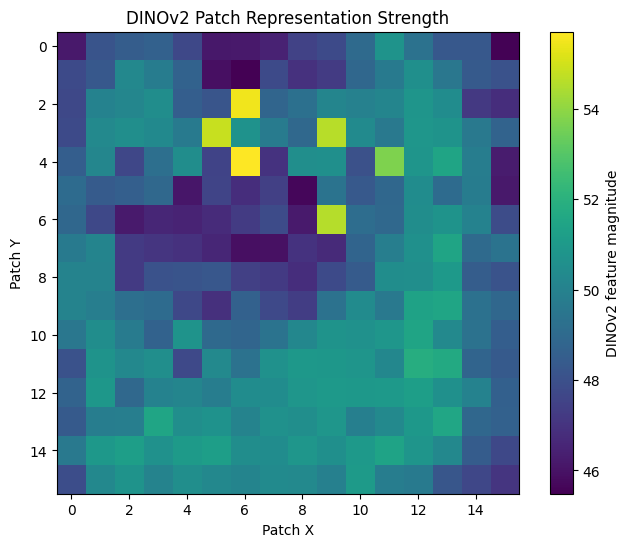

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(patch_map.numpy(), cmap="viridis")
plt.colorbar(label="DINOv2 feature magnitude")

plt.title("DINOv2 Patch Representation Strength")
plt.xlabel("Patch X")
plt.ylabel("Patch Y")

plt.show()

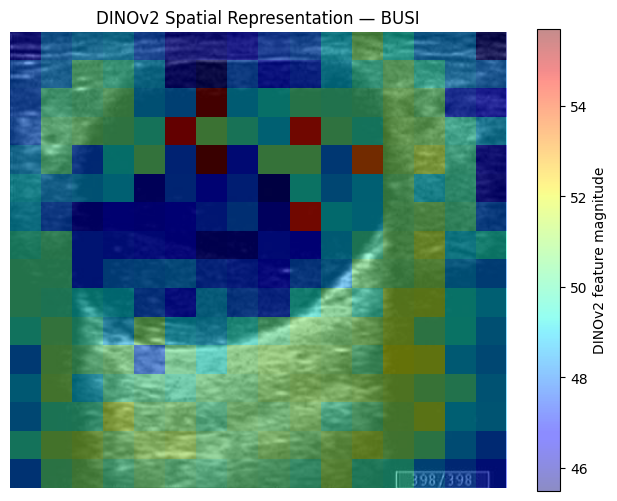

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(image, cmap="gray")

plt.imshow(
    patch_map.numpy(),
    cmap="jet",
    alpha=0.45,
    extent=(0, image.width, image.height, 0)
)

plt.colorbar(label="DINOv2 feature magnitude")

plt.title("DINOv2 Spatial Representation — BUSI")

plt.axis("off")

plt.show()

In [26]:
#comparing with gt 
gt_path = os.path.join(
    r"E:\Research Datasets\BUSI\train\gt",
    os.path.basename(test_image_path).replace(".bmp", "_anno.bmp")
)

gt = Image.open(gt_path).convert("L")

print("GT size:", gt.size)

GT size: (442, 407)


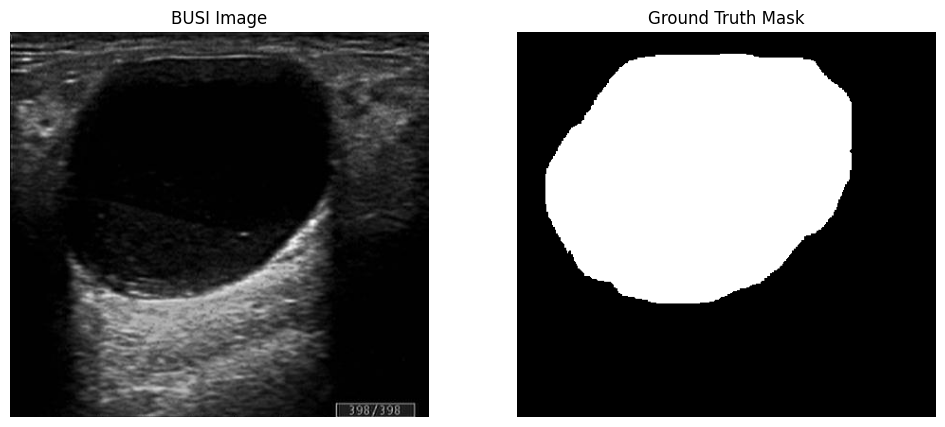

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("BUSI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [31]:
from PIL import Image
import numpy as np

# ---------------------------------------------------------
# Recreate DINO's spatial preprocessing for the GT mask
# ---------------------------------------------------------

# Original GT mask
gt_mask = Image.open(gt_path).convert("L")

print("Original GT size:", gt_mask.size)

# Same resize as DINO
gt_mask_resized = gt_mask.resize(
    (278, 256),
    Image.Resampling.NEAREST
)

# Same center crop as DINO
left = (278 - 224) // 2
top = (256 - 224) // 2

gt_mask_aligned = gt_mask_resized.crop(
    (left, top, left + 224, top + 224)
)

print("Aligned GT size:", gt_mask_aligned.size)

# Binary mask
gt_binary = np.array(gt_mask_aligned) > 0

print("Lesion pixels:", gt_binary.sum())
print("Total pixels:", gt_binary.size)
print("Lesion percentage:",
      100 * gt_binary.mean())

Original GT size: (442, 407)
Aligned GT size: (224, 224)
Lesion pixels: 26223
Total pixels: 50176
Lesion percentage: 52.26203762755102


In [37]:
# Make sure DINO patch strength exists
strength = patch_strength.detach().cpu().numpy()

print("Strength shape:", strength.shape)

# DINOv2 ViT-S/14 should give 256 patch tokens
assert strength.shape[0] == 256, \
    f"Expected 256 patches, got {strength.shape[0]}"

# Convert 256 patches -> 16 x 16 spatial grid
strength_map = strength.reshape(16, 16)

print("Strength map shape:", strength_map.shape)

Strength shape: (256,)
Strength map shape: (16, 16)


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DINO feature strength
# ---------------------------------------------------------

strength = patch_strength.detach().cpu().numpy()
strength_map = strength.reshape(16, 16)


# ---------------------------------------------------------
# Ground-truth mask
# ---------------------------------------------------------

gt_mask = Image.open(gt_path).convert("L")

# Resize exactly as DINO's image preprocessing:
# Resize shorter side to 256
original_w, original_h = gt_mask.size

scale = 256 / min(original_w, original_h)

new_w = round(original_w * scale)
new_h = round(original_h * scale)

gt_resized = gt_mask.resize(
    (new_w, new_h),
    Image.Resampling.NEAREST
)

print("Original GT:", gt_mask.size)
print("Resized GT:", gt_resized.size)


# ---------------------------------------------------------
# Center crop to 224 x 224
# ---------------------------------------------------------

left = (new_w - 224) // 2
top = (new_h - 224) // 2

gt_aligned = gt_resized.crop(
    (left, top, left + 224, top + 224)
)

print("Aligned GT:", gt_aligned.size)


# ---------------------------------------------------------
# Binary mask
# ---------------------------------------------------------

gt_binary = np.array(gt_aligned) > 0


# ---------------------------------------------------------
# Calculate lesion coverage for each DINO patch
# ---------------------------------------------------------

patch_coverage = np.zeros((16, 16))

for y in range(16):
    for x in range(16):

        y1 = y * 14
        y2 = (y + 1) * 14

        x1 = x * 14
        x2 = (x + 1) * 14

        patch_mask = gt_binary[y1:y2, x1:x2]

        patch_coverage[y, x] = patch_mask.mean()


# ---------------------------------------------------------
# Compare lesion vs background
# ---------------------------------------------------------

lesion_patches = strength_map[patch_coverage > 0.25]
background_patches = strength_map[patch_coverage < 0.05]

print("\n-----------------------------")
print("PATCH ANALYSIS")
print("-----------------------------")

print("Total patches:", strength_map.size)
print("Lesion patches:", len(lesion_patches))
print("Background patches:", len(background_patches))

print("\nMean DINO strength:")

if len(lesion_patches):
    print("Lesion:", lesion_patches.mean())

if len(background_patches):
    print("Background:", background_patches.mean())

Original GT: (442, 407)
Resized GT: (278, 256)
Aligned GT: (224, 224)

-----------------------------
PATCH ANALYSIS
-----------------------------
Total patches: 256
Lesion patches: 141
Background patches: 109

Mean DINO strength:
Lesion: 49.013138
Background: 49.68038


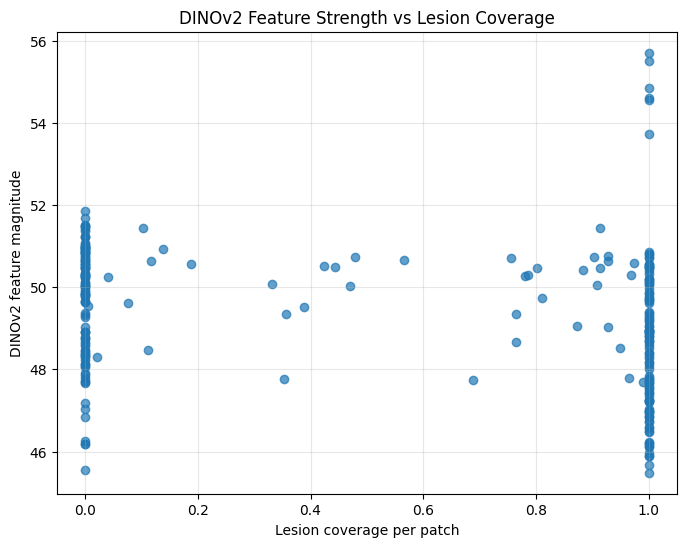

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    patch_coverage.flatten(),
    strength_map.flatten(),
    alpha=0.7
)

plt.xlabel("Lesion coverage per patch")
plt.ylabel("DINOv2 feature magnitude")

plt.title(
    "DINOv2 Feature Strength vs Lesion Coverage"
)

plt.grid(True, alpha=0.3)

plt.show()

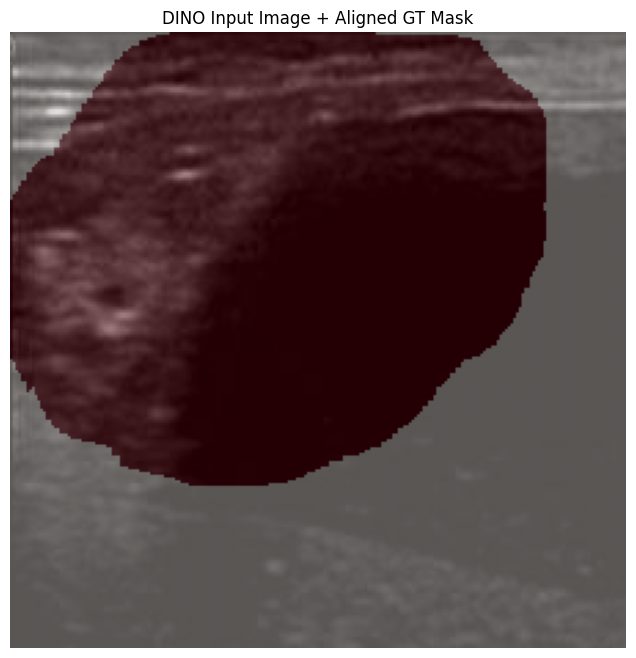

In [36]:
plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.imshow(
    gt_binary,
    cmap="Reds",
    alpha=0.35
)

plt.title("DINO Input Image + Aligned GT Mask")

plt.axis("off")
plt.show()

RETREIVING NEAREST NEIGHBOUR

In [40]:
import numpy as np
import os

feature_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_features.npy"
filename_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_filenames.npy"

features = np.load(feature_path)
filenames = np.load(filename_path)

print("Feature shape:", features.shape)
print("Number of filenames:", len(filenames))
print("First 5 filenames:", filenames[:5])

Feature shape: (555, 384)
Number of filenames: 555
First 5 filenames: ['00001.bmp' '00002.bmp' '00003.bmp' '00006.bmp' '00011.bmp']


In [41]:
query_name = "00001.bmp"

query_idx = np.where(filenames == query_name)[0][0]

print("Query index:", query_idx)
print("Query image:", filenames[query_idx])

Query index: 0
Query image: 00001.bmp


In [42]:
##CALCULATE COSINE SIMILARITY 
from sklearn.metrics.pairwise import cosine_similarity

query_feature = features[query_idx].reshape(1, -1)

similarities = cosine_similarity(
    query_feature,
    features
)[0]

# Don't retrieve the query image itself
similarities[query_idx] = -1

# Get top 5 most similar images
top_indices = np.argsort(similarities)[::-1][:5]

print("Query:", query_name)
print("\nNearest neighbours:")

for rank, idx in enumerate(top_indices, 1):
    print(
        f"{rank}. {filenames[idx]} "
        f"similarity = {similarities[idx]:.4f}"
    )

Query: 00001.bmp

Nearest neighbours:
1. 00395.bmp similarity = 0.7740
2. 00617.bmp similarity = 0.7295
3. 10027-1.bmp similarity = 0.7240
4. 10036-1.bmp similarity = 0.7120
5. 00484.bmp similarity = 0.7014


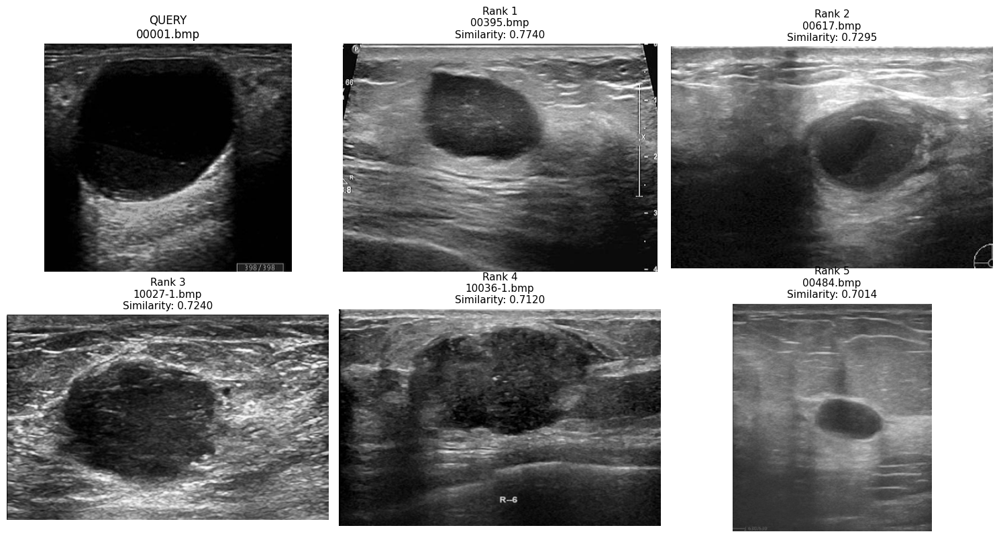

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import os

img_dir = r"E:\Research Datasets\BUSI\train\img"

display_indices = [query_idx] + list(top_indices)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(display_indices):

    img_path = os.path.join(img_dir, str(filenames[idx]))
    img = Image.open(img_path).convert("RGB")

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)
    ax.axis("off")

    if i == 0:
        ax.set_title(
            f"QUERY\n{filenames[idx]}",
            fontsize=12
        )
    else:
        ax.set_title(
            f"Rank {i}\n{filenames[idx]}\n"
            f"Similarity: {similarities[idx]:.4f}",
            fontsize=11
        )

plt.tight_layout()
plt.show()

Features: (555, 384)
Images: 555
Similarity matrix: (555, 555)

Selected queries:
1 00537.bmp
2 00811.bmp
3 00149.bmp
4 00823.bmp
5 00179.bmp
6 00802.bmp
7 00815.bmp
8 00200.bmp
9 10077-5.bmp
10 10071-3.bmp
11 00329.bmp
12 00191.bmp
13 00728.bmp
14 00458.bmp
15 10055-7.bmp
16 00386.bmp
17 00489.bmp
18 00024.bmp
19 00194.bmp
20 00736.bmp


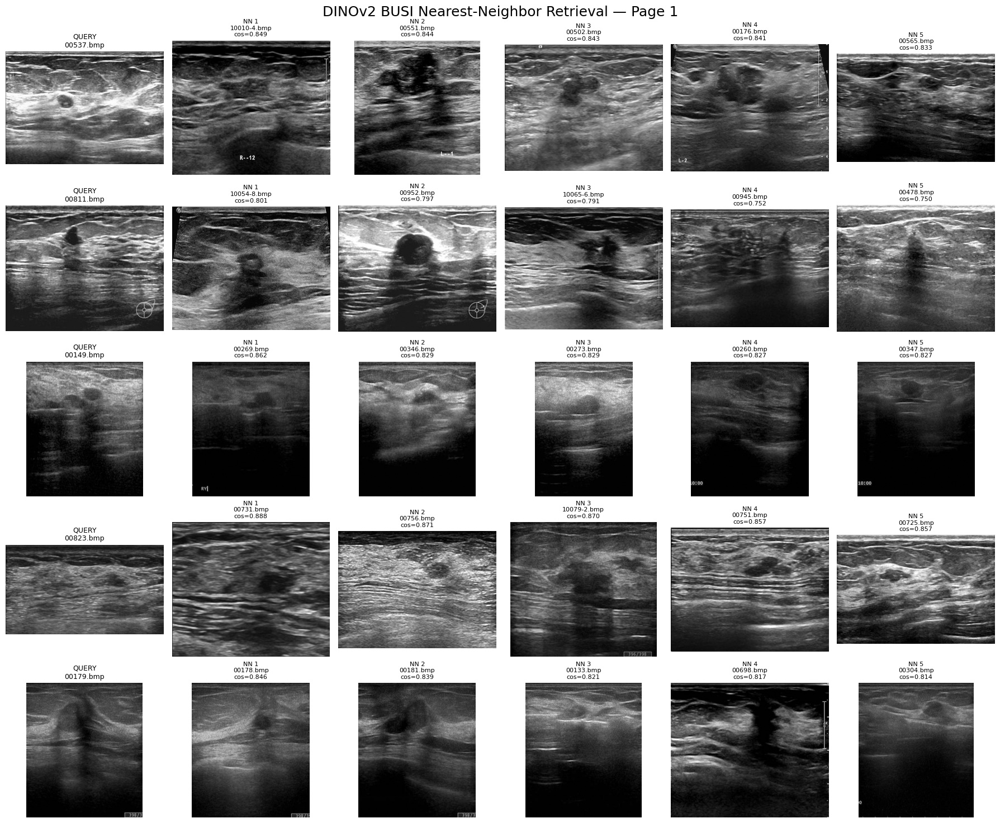

Saved: E:\Research Datasets\BUSI\dinov2_retrieval_page_1.png


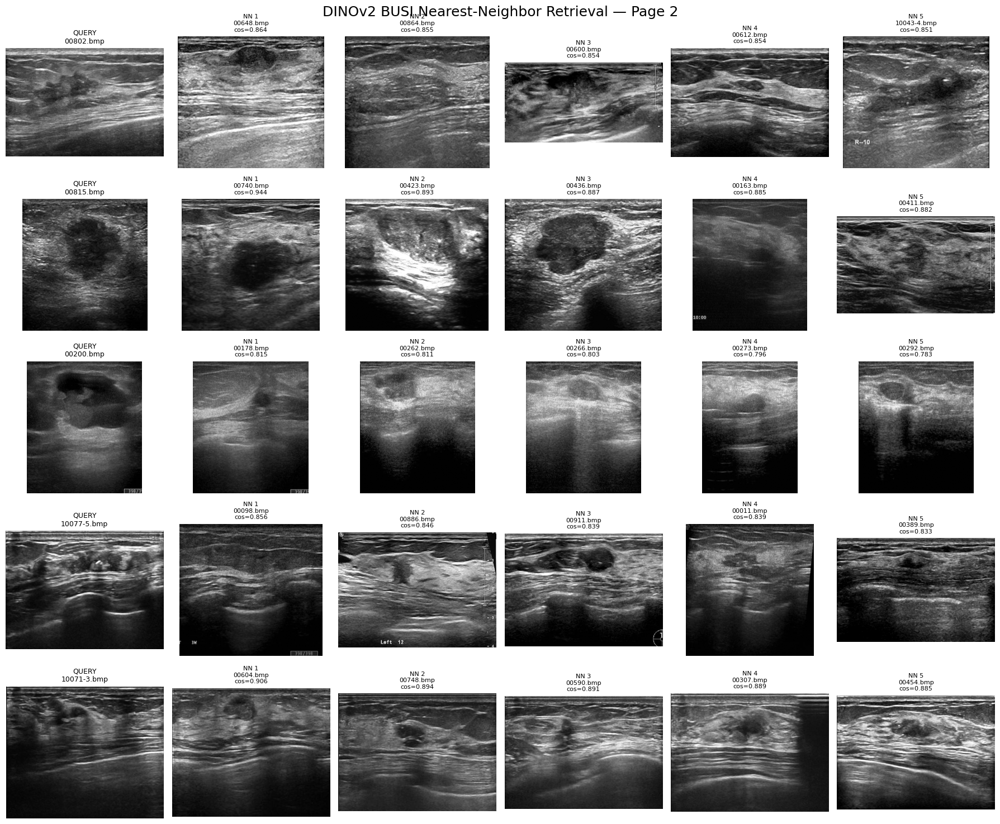

Saved: E:\Research Datasets\BUSI\dinov2_retrieval_page_2.png


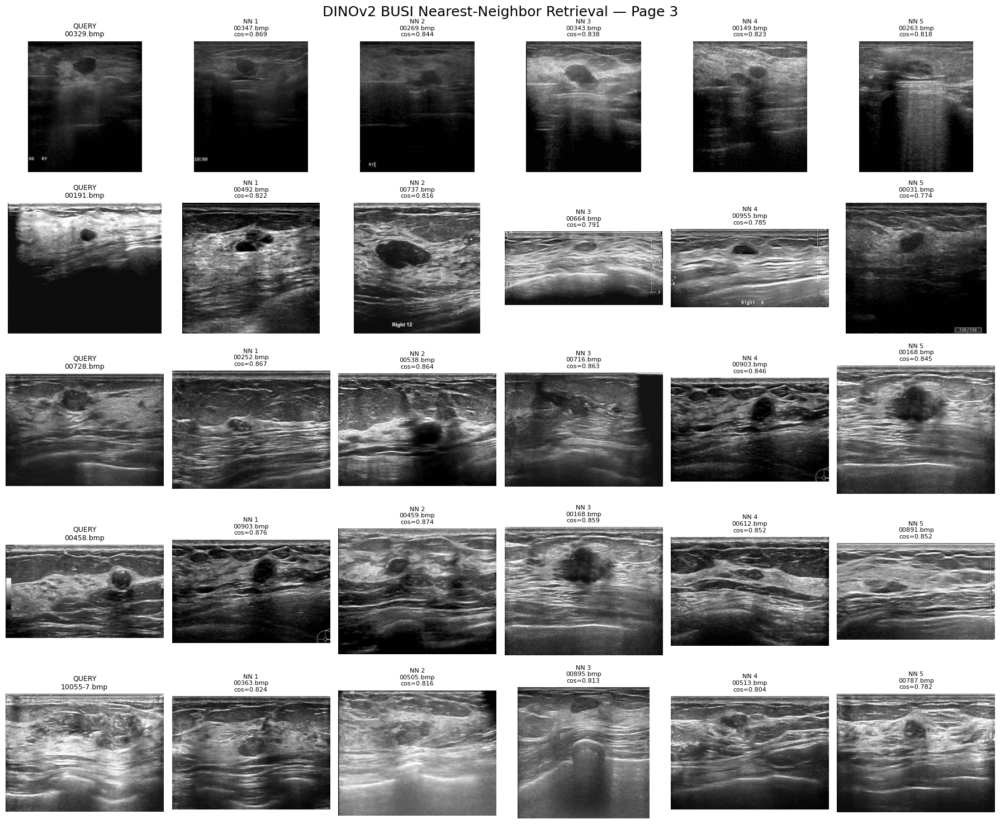

Saved: E:\Research Datasets\BUSI\dinov2_retrieval_page_3.png


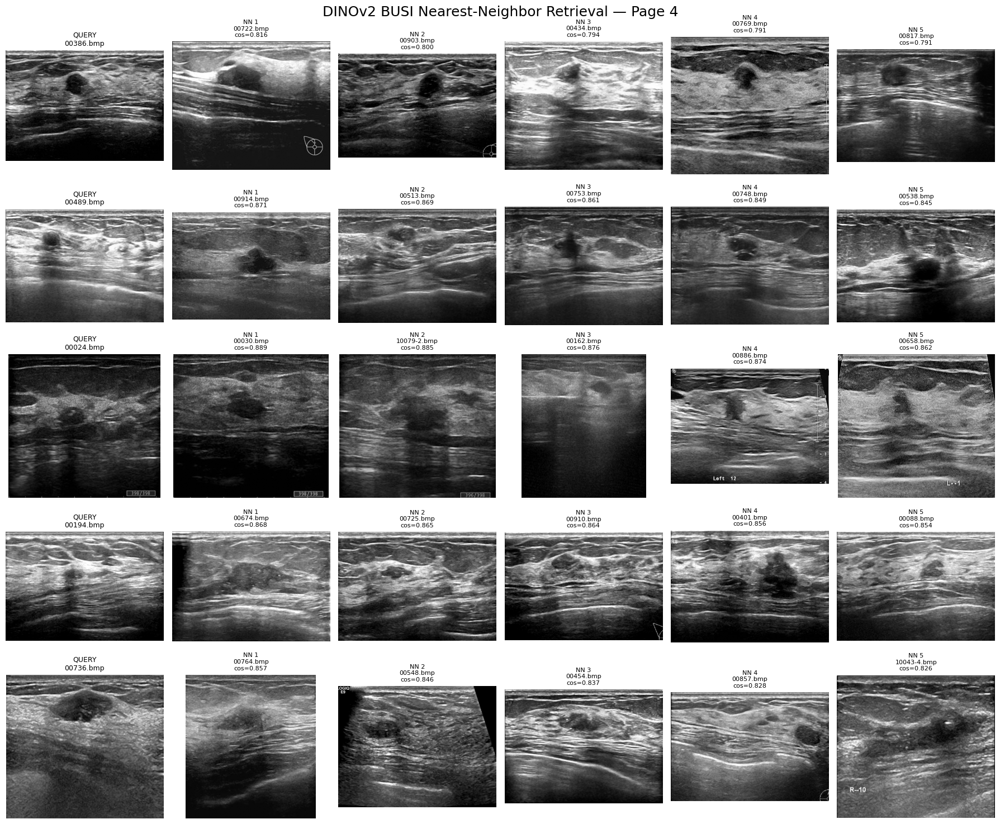

Saved: E:\Research Datasets\BUSI\dinov2_retrieval_page_4.png


In [44]:
import numpy as np
import os
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------

feature_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_features.npy"
filename_path = r"E:\Research Datasets\BUSI\busi_train_dinov2_filenames.npy"
img_dir = r"E:\Research Datasets\BUSI\train\img"

# --------------------------------------------------
# 2. Load DINOv2 features
# --------------------------------------------------

features = np.load(feature_path)
filenames = np.load(filename_path)

print("Features:", features.shape)
print("Images:", len(filenames))

# --------------------------------------------------
# 3. Normalize features
# --------------------------------------------------
# This makes cosine similarity computation efficient
# and numerically stable.

features_norm = features / np.linalg.norm(
    features, axis=1, keepdims=True
)

# --------------------------------------------------
# 4. Compute similarity between ALL images
# --------------------------------------------------

similarity_matrix = features_norm @ features_norm.T

print("Similarity matrix:", similarity_matrix.shape)

# --------------------------------------------------
# 5. Randomly select 20 query images
# --------------------------------------------------

np.random.seed(42)

query_indices = np.random.choice(
    len(filenames),
    size=20,
    replace=False
)

print("\nSelected queries:")
for i, idx in enumerate(query_indices, 1):
    print(i, filenames[idx])

# --------------------------------------------------
# 6. Retrieve 5 nearest neighbours
# --------------------------------------------------

all_results = {}

for query_idx in query_indices:

    similarities = similarity_matrix[query_idx].copy()

    # Remove the query itself
    similarities[query_idx] = -1

    # Highest similarity first
    neighbour_indices = np.argsort(similarities)[::-1][:5]

    all_results[query_idx] = neighbour_indices

# --------------------------------------------------
# 7. Create four gallery figures
# --------------------------------------------------
# Each figure contains 5 queries.
#
# Each row:
#
# Query | NN1 | NN2 | NN3 | NN4 | NN5

for page in range(4):

    start = page * 5
    end = start + 5

    page_queries = query_indices[start:end]

    fig, axes = plt.subplots(
        5,
        6,
        figsize=(18, 15)
    )

    fig.suptitle(
        f"DINOv2 BUSI Nearest-Neighbor Retrieval — Page {page + 1}",
        fontsize=18
    )

    for row, query_idx in enumerate(page_queries):

        neighbour_indices = all_results[query_idx]

        # Query + 5 neighbours
        display_indices = [
            query_idx
        ] + list(neighbour_indices)

        for col, idx in enumerate(display_indices):

            filename = str(filenames[idx])
            image_path = os.path.join(img_dir, filename)

            try:
                image = Image.open(image_path).convert("L")

                axes[row, col].imshow(
                    image,
                    cmap="gray"
                )

                axes[row, col].axis("off")

                # Query
                if col == 0:

                    axes[row, col].set_title(
                        f"QUERY\n{filename}",
                        fontsize=9
                    )

                # Neighbour
                else:

                    similarity = similarity_matrix[
                        query_idx,
                        idx
                    ]

                    axes[row, col].set_title(
                        f"NN {col}\n"
                        f"{filename}\n"
                        f"cos={similarity:.3f}",
                        fontsize=8
                    )

            except Exception as e:

                axes[row, col].text(
                    0.5,
                    0.5,
                    f"Error\n{filename}",
                    ha="center",
                    va="center"
                )

                axes[row, col].axis("off")

    plt.tight_layout()

    # Save the gallery
    output_path = os.path.join(
        r"E:\Research Datasets\BUSI",
        f"dinov2_retrieval_page_{page + 1}.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {output_path}"
    )

SO NOW AFTER SEEING THESE RESULTS WE CAN CLAIM "DINOv2 produces semantically meaningful visual representations for BUSI ultrasound images, despite being pretrained on natural images rather than ultrasound data."

NOW CHECK "If two images are close in DINO feature space, are their lesion masks also similar?"  For every query image:

Take its DINOv2 384-D embedding.
Find its top-5 nearest neighbours using cosine similarity.
Load the query's GT mask.
Load each neighbour's GT mask.
Calculate Dice similarity between the two masks.
Compare:
DINO cosine similarity
GT-mask Dice similarity

If DINO is learning useful lesion-related representations, we'd hope to see a positive relationship: higher DINO similarity → generally higher GT similarity.

In [45]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, pearsonr

# ============================================================
# PATHS
# ============================================================

ROOT = r"E:\Research Datasets\BUSI"

IMG_DIR = os.path.join(ROOT, "train", "img")
GT_DIR = os.path.join(ROOT, "train", "gt")

FEATURE_FILE = os.path.join(ROOT, "busi_train_dinov2_features.npy")
FILENAME_FILE = os.path.join(ROOT, "busi_train_dinov2_filenames.npy")


# ============================================================
# LOAD DINO FEATURES
# ============================================================

features = np.load(FEATURE_FILE)
filenames = np.load(FILENAME_FILE)

print("Feature matrix:", features.shape)
print("Number of filenames:", len(filenames))

# Normalize features for cosine similarity
features_norm = features / np.linalg.norm(
    features, axis=1, keepdims=True
)

print("DINO features loaded.")

Feature matrix: (555, 384)
Number of filenames: 555
DINO features loaded.


In [46]:
def get_gt_path(filename):
    base = os.path.splitext(filename)[0]
    return os.path.join(GT_DIR, base + "_anno.bmp")

print(get_gt_path("00001.bmp"))

E:\Research Datasets\BUSI\train\gt\00001_anno.bmp


In [47]:
def load_mask(filename):
    
    path = get_gt_path(filename)
    
    mask = Image.open(path).convert("L")
    
    # Same spatial transformation as the DINO input
    mask = mask.resize((256, 256), Image.Resampling.NEAREST)
    
    # Center crop 224 x 224
    left = (256 - 224) // 2
    top = (256 - 224) // 2
    
    mask = mask.crop((
        left,
        top,
        left + 224,
        top + 224
    ))
    
    mask = np.array(mask)
    
    # Convert to binary
    mask = mask > 0
    
    return mask

In [48]:
def dice_score(mask1, mask2):
    
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)
    
    intersection = np.logical_and(mask1, mask2).sum()
    
    denominator = mask1.sum() + mask2.sum()
    
    if denominator == 0:
        return 1.0
    
    return (2.0 * intersection) / denominator

In [49]:
query_name = "00001.bmp"

mask = load_mask(query_name)

print("Mask shape:", mask.shape)
print("Lesion pixels:", mask.sum())
print("Lesion coverage:", mask.mean())

Mask shape: (224, 224)
Lesion pixels: 24449
Lesion coverage: 0.48726482780612246


In [50]:
query_idx = np.where(filenames == query_name)[0][0]

query_feature = features_norm[query_idx].reshape(1, -1)

similarities = cosine_similarity(
    query_feature,
    features_norm
)[0]

# Don't retrieve the query itself
similarities[query_idx] = -1

# Top 5
top_indices = np.argsort(similarities)[::-1][:5]

print("Query:", query_name)
print("\nNearest neighbours:")

for rank, idx in enumerate(top_indices, 1):
    print(
        f"{rank}. {filenames[idx]} "
        f"cosine={similarities[idx]:.4f}"
    )

Query: 00001.bmp

Nearest neighbours:
1. 00395.bmp cosine=0.7740
2. 00617.bmp cosine=0.7295
3. 10027-1.bmp cosine=0.7240
4. 10036-1.bmp cosine=0.7120
5. 00484.bmp cosine=0.7014


In [51]:
query_mask = load_mask(query_name)

print("\nGT similarity:")

for rank, idx in enumerate(top_indices, 1):
    
    neighbour_name = filenames[idx]
    
    neighbour_mask = load_mask(neighbour_name)
    
    dice = dice_score(
        query_mask,
        neighbour_mask
    )
    
    cosine = similarities[idx]
    
    print(
        f"{rank}. {neighbour_name} | "
        f"DINO cosine = {cosine:.4f} | "
        f"GT Dice = {dice:.4f}"
    )


GT similarity:
1. 00395.bmp | DINO cosine = 0.7740 | GT Dice = 0.4718
2. 00617.bmp | DINO cosine = 0.7295 | GT Dice = 0.4262
3. 10027-1.bmp | DINO cosine = 0.7240 | GT Dice = 0.6422
4. 10036-1.bmp | DINO cosine = 0.7120 | GT Dice = 0.7865
5. 00484.bmp | DINO cosine = 0.7014 | GT Dice = 0.1863


A low GT Dice does not mean DINO is performing poorly in this experiment. Dice is measuring something very specific: overlap between two lesion masks. DINO cosine similarity is measuring similarity of the entire image representation.

So your result suggests: "DINOv2's notion of image similarity is broader than simply matching lesion-mask geometry."

In [52]:
import numpy as np
import os
from PIL import Image
from scipy.stats import spearmanr, pearsonr

# ============================================================
# PATHS
# ============================================================

ROOT = r"E:\Research Datasets\BUSI"

GT_DIR = os.path.join(ROOT, "train", "gt")

FEATURE_FILE = os.path.join(
    ROOT, "busi_train_dinov2_features.npy"
)

FILENAME_FILE = os.path.join(
    ROOT, "busi_train_dinov2_filenames.npy"
)

# ============================================================
# LOAD DINO FEATURES
# ============================================================

features = np.load(FEATURE_FILE)
filenames = np.load(FILENAME_FILE)

print("Features:", features.shape)
print("Images:", len(filenames))

# Normalize for cosine similarity
features_norm = features / np.linalg.norm(
    features,
    axis=1,
    keepdims=True
)

# ============================================================
# PRE-COMPUTE ALL DINO SIMILARITIES
# ============================================================

similarity_matrix = features_norm @ features_norm.T

print("Similarity matrix:", similarity_matrix.shape)

# ============================================================
# LOAD MASKS
# ============================================================

def get_gt_path(filename):
    base = os.path.splitext(str(filename))[0]
    return os.path.join(
        GT_DIR,
        base + "_anno.bmp"
    )


def load_mask(filename):

    path = get_gt_path(filename)

    mask = Image.open(path).convert("L")

    # Same spatial transformation used for DINO input
    mask = mask.resize(
        (256, 256),
        Image.Resampling.NEAREST
    )

    # Center crop to 224 x 224
    left = (256 - 224) // 2
    top = (256 - 224) // 2

    mask = mask.crop(
        (
            left,
            top,
            left + 224,
            top + 224
        )
    )

    mask = np.array(mask)

    # Binary mask
    return mask > 0


# ============================================================
# LOAD ALL 555 MASKS ONCE
# ============================================================

print("\nLoading GT masks...")

masks = []

for i, filename in enumerate(filenames):

    masks.append(load_mask(filename))

    if (i + 1) % 100 == 0:
        print(f"Loaded {i + 1}/{len(filenames)} masks")

print("All masks loaded.")

# ============================================================
# DICE FUNCTION
# ============================================================

def dice_score(mask1, mask2):

    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)

    intersection = np.logical_and(
        mask1,
        mask2
    ).sum()

    denominator = (
        mask1.sum() +
        mask2.sum()
    )

    if denominator == 0:
        return 1.0

    return (
        2.0 * intersection
    ) / denominator


# ============================================================
# RETRIEVE TOP-5 AND COMPARE MASKS
# ============================================================

dino_scores = []
dice_scores = []

pair_records = []

print("\nRunning retrieval + GT comparison...")

for query_idx in range(len(filenames)):

    similarities = similarity_matrix[
        query_idx
    ].copy()

    # Exclude the image itself
    similarities[query_idx] = -1

    # Top 5 neighbours
    neighbour_indices = np.argsort(
        similarities
    )[::-1][:5]

    query_mask = masks[query_idx]

    for neighbour_idx in neighbour_indices:

        dino_similarity = similarities[
            neighbour_idx
        ]

        neighbour_mask = masks[
            neighbour_idx
        ]

        dice = dice_score(
            query_mask,
            neighbour_mask
        )

        dino_scores.append(
            dino_similarity
        )

        dice_scores.append(
            dice
        )

        pair_records.append(
            (
                str(filenames[query_idx]),
                str(filenames[neighbour_idx]),
                dino_similarity,
                dice
            )
        )

    if (query_idx + 1) % 50 == 0:
        print(
            f"Processed "
            f"{query_idx + 1}/{len(filenames)} images"
        )


# ============================================================
# CONVERT TO ARRAYS
# ============================================================

dino_scores = np.array(dino_scores)
dice_scores = np.array(dice_scores)

print("\nFinished!")
print(
    "Total image pairs:",
    len(dino_scores)
)

# ============================================================
# CORRELATIONS
# ============================================================

pearson_r, pearson_p = pearsonr(
    dino_scores,
    dice_scores
)

spearman_rho, spearman_p = spearmanr(
    dino_scores,
    dice_scores
)

print("\n================================")
print("CORRELATION RESULTS")
print("================================")

print(
    f"Pearson r     = {pearson_r:.4f}"
)

print(
    f"Pearson p     = {pearson_p:.6e}"
)

print(
    f"Spearman rho  = {spearman_rho:.4f}"
)

print(
    f"Spearman p    = {spearman_p:.6e}"
)

print("================================")

Features: (555, 384)
Images: 555
Similarity matrix: (555, 555)

Loading GT masks...
Loaded 100/555 masks
Loaded 200/555 masks
Loaded 300/555 masks
Loaded 400/555 masks
Loaded 500/555 masks
All masks loaded.

Running retrieval + GT comparison...
Processed 50/555 images
Processed 100/555 images
Processed 150/555 images
Processed 200/555 images
Processed 250/555 images
Processed 300/555 images
Processed 350/555 images
Processed 400/555 images
Processed 450/555 images
Processed 500/555 images
Processed 550/555 images

Finished!
Total image pairs: 2775

CORRELATION RESULTS
Pearson r     = -0.0502
Pearson p     = 8.202168e-03
Spearman rho  = -0.0537
Spearman p    = 4.655856e-03


THESE RESULTS SHOWS THAT "DINO's global representation captures meaningful image-level similarity, but that similarity is not strongly aligned with exact lesion-mask geometry."

patch-level experiment.

In [53]:
import torch
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

ROOT = r"E:\Research Datasets\BUSI"

img_path = os.path.join(
    ROOT, "train", "img", "00001.bmp"
)

gt_path = os.path.join(
    ROOT, "train", "gt", "00001_anno.bmp"
)

# --------------------------------------------------
# Load DINOv2
# --------------------------------------------------

print("Loading DINOv2...")

dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

dinov2.eval()

print("DINOv2 loaded.")

Loading DINOv2...


Using cache found in C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 loaded.


In [54]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(
        256,
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

image = Image.open(img_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0)

print("Original image:", image.size)
print("DINO input:", input_tensor.shape)

Original image: (442, 407)
DINO input: torch.Size([1, 3, 224, 224])


In [55]:
#EXTRACT THE ACTUAL PATCH TOKENS 
with torch.no_grad():

    output = dinov2.forward_features(
        input_tensor
    )

patch_tokens = output[
    "x_norm_patchtokens"
]

print("Patch token shape:", patch_tokens.shape)

Patch token shape: torch.Size([1, 256, 384])


In [56]:
patch_tokens = patch_tokens.squeeze(0)

print("Patch tokens:", patch_tokens.shape)

Patch tokens: torch.Size([256, 384])


In [57]:
mask = Image.open(gt_path).convert("L")

print("Original mask size:", mask.size)

mask = mask.resize(
    (256, 256),
    Image.Resampling.NEAREST
)

mask = mask.crop(
    (16, 16, 240, 240)
)

mask = np.array(mask)

binary_mask = mask > 0

print("Processed mask shape:", binary_mask.shape)
print("Lesion pixels:", binary_mask.sum())

Original mask size: (442, 407)
Processed mask shape: (224, 224)
Lesion pixels: 24449


In [58]:
patch_mask = np.zeros(
    (16, 16),
    dtype=np.float32
)

for row in range(16):

    for col in range(16):

        y1 = row * 14
        y2 = (row + 1) * 14

        x1 = col * 14
        x2 = (col + 1) * 14

        patch = binary_mask[
            y1:y2,
            x1:x2
        ]

        patch_mask[row, col] = patch.mean()

print(
    "Patch mask shape:",
    patch_mask.shape
)

print(
    "Minimum lesion coverage:",
    patch_mask.min()
)

print(
    "Maximum lesion coverage:",
    patch_mask.max()
)

Patch mask shape: (16, 16)
Minimum lesion coverage: 0.0
Maximum lesion coverage: 1.0


In [59]:
lesion_patch_mask = patch_mask >= 0.5

print(
    "Total patches:",
    lesion_patch_mask.size
)

print(
    "Lesion patches:",
    lesion_patch_mask.sum()
)

print(
    "Background patches:",
    (~lesion_patch_mask).sum()
)

Total patches: 256
Lesion patches: 126
Background patches: 130


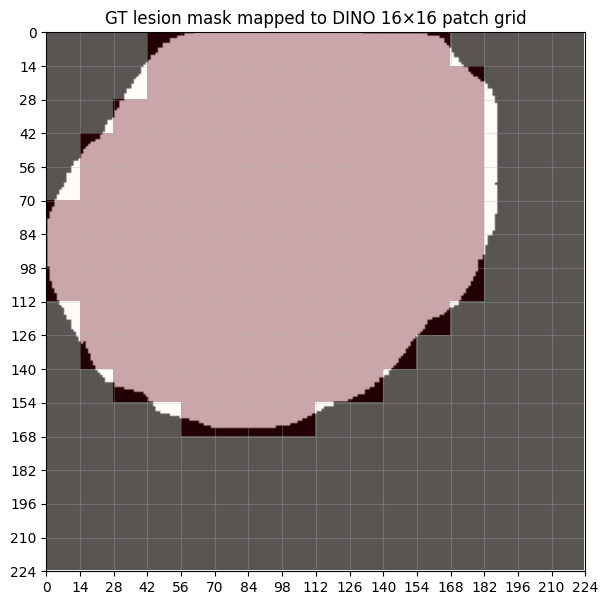

In [60]:
plt.figure(figsize=(7, 7))

plt.imshow(binary_mask, cmap="gray")

plt.imshow(
    lesion_patch_mask,
    cmap="Reds",
    alpha=0.35,
    extent=[
        0,
        224,
        224,
        0
    ],
    interpolation="nearest"
)

plt.xticks(
    np.arange(0, 225, 14)
)

plt.yticks(
    np.arange(0, 225, 14)
)

plt.grid(
    True,
    alpha=0.3
)

plt.title(
    "GT lesion mask mapped to DINO 16×16 patch grid"
)

plt.show()

In [61]:
patch_labels = lesion_patch_mask.flatten()

print("Patch features:", patch_tokens.shape)
print("Patch labels:", patch_labels.shape)

print("Lesion patches:", patch_labels.sum())
print("Background patches:", (~patch_labels).sum())

Patch features: torch.Size([256, 384])
Patch labels: (256,)
Lesion patches: 126
Background patches: 130


In [62]:
patch_features = patch_tokens.numpy()

lesion_features = patch_features[patch_labels]
background_features = patch_features[~patch_labels]

print("Lesion feature matrix:",
      lesion_features.shape)

print("Background feature matrix:",
      background_features.shape)

Lesion feature matrix: (126, 384)
Background feature matrix: (130, 384)


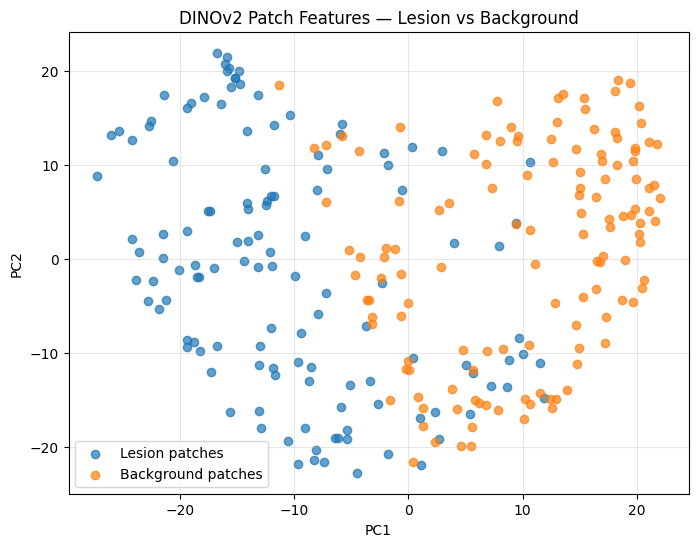

Variance explained: [0.21008815 0.16342595]


In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

all_features = np.vstack([
    lesion_features,
    background_features
])

features_2d = pca.fit_transform(all_features)

n_lesion = len(lesion_features)

plt.figure(figsize=(8, 6))

plt.scatter(
    features_2d[:n_lesion, 0],
    features_2d[:n_lesion, 1],
    alpha=0.7,
    label="Lesion patches"
)

plt.scatter(
    features_2d[n_lesion:, 0],
    features_2d[n_lesion:, 1],
    alpha=0.7,
    label="Background patches"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DINOv2 Patch Features — Lesion vs Background")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(
    "Variance explained:",
    pca.explained_variance_ratio_
)

after visualizing the results of patch level represenatation,We're going to take those 384-dimensional DINO patch embeddings and train a very small classifier on top of them.

Something like:

BUSI image
     ↓
DINOv2
     ↓
256 patches
     ↓
384-D embedding for each patch
     ↓
tiny classifier
     ↓
Lesion / Background. 

the question is : Can a simple classifier use the information already present in DINOv2's patch representations to distinguish lesion from background?

but we dont have labels, but we have gt for each img. The GT mask tells us which pixels belong to the lesion.

We can convert that pixel-level GT into patch-level labels:

GT mask
   ↓
resize/alignment to 16×16 DINO patch grid
   ↓
256 patches
   ↓
each patch = 
    1 → lesion
    0 → background

So yes, we do have labels. They're simply stored as mask images rather than a CSV.

In [64]:
import os
import numpy as np
from PIL import Image

import torch
import torchvision.transforms as T

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ============================================================
# 1. PATHS
# ============================================================

ROOT = r"E:\Research Datasets\BUSI"

TRAIN_IMG = os.path.join(ROOT, "train", "img")
TRAIN_GT  = os.path.join(ROOT, "train", "gt")

VALID_IMG = os.path.join(ROOT, "valid", "img")
VALID_GT  = os.path.join(ROOT, "valid", "gt")


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ============================================================
# 3. LOAD DINOv2
# ============================================================

print("\nLoading DINOv2...")

dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

dinov2 = dinov2.to(device)
dinov2.eval()

print("DINOv2 loaded.")


# ============================================================
# 4. IMAGE TRANSFORM
# ============================================================

image_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


# ============================================================
# 5. GT TRANSFORM
#
# IMPORTANT:
# We apply the SAME spatial operations to the GT mask:
# Resize 256 → CenterCrop 224
#
# But we DON'T normalize the mask.
# ============================================================

gt_transform = T.Compose([
    T.Resize(
        256,
        interpolation=T.InterpolationMode.NEAREST
    ),
    T.CenterCrop(224)
])


# ============================================================
# 6. EXTRACT DINO PATCH FEATURES
# ============================================================

def extract_patch_features(img_path):

    image = Image.open(img_path).convert("RGB")

    image_tensor = image_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = dinov2.forward_features(image_tensor)

        patch_tokens = output["x_norm_patchtokens"]

    # Shape:
    # [1, 256, 384]

    patch_tokens = patch_tokens.squeeze(0).cpu().numpy()

    return patch_tokens


# ============================================================
# 7. CREATE PATCH LABELS FROM GT MASK
# ============================================================

def get_patch_labels(gt_path):

    mask = Image.open(gt_path).convert("L")

    # Same spatial alignment as DINO input
    mask = gt_transform(mask)

    mask = np.array(mask)

    # Binary mask
    mask = mask > 0

    # --------------------------------------------------------
    # 224 x 224 image
    # DINO patch size = 14 x 14
    # Therefore:
    #
    # 224 / 14 = 16
    #
    # 16 x 16 = 256 patches
    # --------------------------------------------------------

    patch_labels = []

    patch_size = 14

    for row in range(16):

        for col in range(16):

            y1 = row * patch_size
            y2 = (row + 1) * patch_size

            x1 = col * patch_size
            x2 = (col + 1) * patch_size

            patch = mask[y1:y2, x1:x2]

            # Fraction of pixels belonging to lesion
            lesion_fraction = patch.mean()

            # Label patch as lesion if at least 50%
            # of its pixels are lesion.
            label = lesion_fraction >= 0.5

            patch_labels.append(label)

    return np.array(patch_labels)


# ============================================================
# 8. FIND MATCHING GT
# ============================================================

def get_gt_path(gt_folder, image_filename):

    base = os.path.splitext(image_filename)[0]

    gt_filename = base + "_anno.bmp"

    gt_path = os.path.join(gt_folder, gt_filename)

    return gt_path


# ============================================================
# 9. BUILD DATASET
# ============================================================

def build_patch_dataset(img_folder, gt_folder):

    image_files = sorted([
        f for f in os.listdir(img_folder)
        if f.lower().endswith(".bmp")
    ])

    print("\nImages found:", len(image_files))

    all_features = []
    all_labels = []

    for i, filename in enumerate(image_files):

        img_path = os.path.join(img_folder, filename)

        gt_path = get_gt_path(
            gt_folder,
            filename
        )

        if not os.path.exists(gt_path):

            print("WARNING: GT missing:", filename)
            continue

        # --------------------------------------------
        # DINO patch features
        # --------------------------------------------

        features = extract_patch_features(img_path)

        # --------------------------------------------
        # GT patch labels
        # --------------------------------------------

        labels = get_patch_labels(gt_path)

        # --------------------------------------------
        # Sanity check
        # --------------------------------------------

        if features.shape != (256, 384):

            print(
                "Unexpected feature shape:",
                filename,
                features.shape
            )

            continue

        if labels.shape != (256,):

            print(
                "Unexpected label shape:",
                filename,
                labels.shape
            )

            continue

        all_features.append(features)
        all_labels.append(labels.astype(np.int32))

        if (i + 1) % 50 == 0:

            print(
                f"Processed {i+1}/{len(image_files)}"
            )

    # ------------------------------------------------
    # Combine everything
    # ------------------------------------------------

    X = np.vstack(all_features)
    y = np.concatenate(all_labels)

    return X, y


# ============================================================
# 10. TRAIN DATA
# ============================================================

print("\n========================================")
print("BUILDING TRAIN PATCH DATASET")
print("========================================")

X_train, y_train = build_patch_dataset(
    TRAIN_IMG,
    TRAIN_GT
)

print("\nTRAIN FEATURES:", X_train.shape)
print("TRAIN LABELS:", y_train.shape)

print(
    "Train lesion patches:",
    np.sum(y_train == 1)
)

print(
    "Train background patches:",
    np.sum(y_train == 0)
)


# ============================================================
# 11. VALIDATION DATA
# ============================================================

print("\n========================================")
print("BUILDING VALIDATION PATCH DATASET")
print("========================================")

X_valid, y_valid = build_patch_dataset(
    VALID_IMG,
    VALID_GT
)

print("\nVALID FEATURES:", X_valid.shape)
print("VALID LABELS:", y_valid.shape)

print(
    "Valid lesion patches:",
    np.sum(y_valid == 1)
)

print(
    "Valid background patches:",
    np.sum(y_valid == 0)
)


# ============================================================
# 12. TRAIN LOGISTIC REGRESSION
# ============================================================

print("\n========================================")
print("TRAINING LOGISTIC REGRESSION")
print("========================================")

classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

classifier.fit(
    X_train,
    y_train
)

print("Classifier trained.")


# ============================================================
# 13. PREDICTIONS
# ============================================================

print("\nRunning validation predictions...")

y_pred = classifier.predict(X_valid)

y_prob = classifier.predict_proba(
    X_valid
)[:, 1]


# ============================================================
# 14. METRICS
# ============================================================

accuracy = accuracy_score(
    y_valid,
    y_pred
)

precision = precision_score(
    y_valid,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_valid,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_valid,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_valid,
    y_prob
)


# ============================================================
# 15. IoU
# ============================================================

intersection = np.sum(
    (y_pred == 1) & (y_valid == 1)
)

union = np.sum(
    (y_pred == 1) | (y_valid == 1)
)

iou = intersection / union if union > 0 else 0


# ============================================================
# 16. DICE
# ============================================================

dice = (
    2 * intersection
    /
    (
        np.sum(y_pred == 1)
        +
        np.sum(y_valid == 1)
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_valid,
    y_pred
)


# ============================================================
# 18. PRINT RESULTS
# ============================================================

print("\n========================================")
print("DINOv2 + LOGISTIC REGRESSION RESULTS")
print("========================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"Dice      : {dice:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\n========================================")

Device: cpu

Loading DINOv2...


Using cache found in C:\Users\Home/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 loaded.

BUILDING TRAIN PATCH DATASET

Images found: 555
Processed 50/555
Processed 100/555
Processed 150/555
Processed 200/555
Processed 250/555
Processed 300/555
Processed 350/555
Processed 400/555
Processed 450/555
Processed 500/555
Processed 550/555

TRAIN FEATURES: (142080, 384)
TRAIN LABELS: (142080,)
Train lesion patches: 14849
Train background patches: 127231

BUILDING VALIDATION PATCH DATASET

Images found: 186
Processed 50/186
Processed 100/186
Processed 150/186

VALID FEATURES: (47616, 384)
VALID LABELS: (47616,)
Valid lesion patches: 4821
Valid background patches: 42795

TRAINING LOGISTIC REGRESSION
Classifier trained.

Running validation predictions...

DINOv2 + LOGISTIC REGRESSION RESULTS
Accuracy  : 0.9262
Precision : 0.5897
Recall    : 0.8909
F1-score  : 0.7097
IoU       : 0.5500
Dice      : 0.7097
ROC-AUC   : 0.9715

Confusion Matrix:
[[39807  2988]
 [  526  4295]]



These preliminary results suggest that frozen DINOv2 patch representations contain useful transferable information for distinguishing lesion-containing regions from background in BUSI, despite DINOv2 not being trained specifically on ultrasound images.

In [1]:
import os
import shutil
import pandas as pd

# ============================================================
# CHANGE ONLY THIS PATH
# ============================================================

SOURCE_DIR = r"E:\Research Datasets\Datasets\BrEaST-Lesions_USG-images_and_masks"

# These folders already exist inside SOURCE_DIR
IMAGE_DIR = os.path.join(SOURCE_DIR, "images")
MASK_DIR = os.path.join(SOURCE_DIR, "masks")

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)


# ============================================================
# FIND FILES
# ============================================================

files = os.listdir(SOURCE_DIR)

image_files = []
mask_files = []

for f in files:

    if not f.lower().endswith(".png"):
        continue

    if f.lower().endswith("_tumor.png"):
        mask_files.append(f)
    else:
        image_files.append(f)


print("=" * 60)
print("BREAST-LESIONS-USG")
print("=" * 60)

print("Images found:", len(image_files))
print("Masks found :", len(mask_files))


# ============================================================
# CREATE MASK LOOKUP
# ============================================================

mask_lookup = {}

for mask in mask_files:

    case_id = mask.replace("_tumor.png", "")

    mask_lookup[case_id] = mask


# ============================================================
# MOVE FILES
# ============================================================

mapping = []

matched = 0
unmatched = 0

for image in sorted(image_files):

    case_id = image.replace(".png", "")

    if case_id in mask_lookup:

        mask = mask_lookup[case_id]

        # Move image
        shutil.move(
            os.path.join(SOURCE_DIR, image),
            os.path.join(IMAGE_DIR, image)
        )

        # Move mask
        shutil.move(
            os.path.join(SOURCE_DIR, mask),
            os.path.join(MASK_DIR, mask)
        )

        mapping.append({
            "case_id": case_id,
            "image_file": image,
            "mask_file": mask
        })

        matched += 1

    else:

        print("WARNING: No mask for", image)
        unmatched += 1


# ============================================================
# SAVE MAPPING
# ============================================================

df = pd.DataFrame(mapping)

df.to_csv(
    os.path.join(SOURCE_DIR, "mapping.csv"),
    index=False
)


# ============================================================
# REPORT
# ============================================================

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

print("Matched pairs :", matched)
print("Unmatched     :", unmatched)

print("\nImages folder:", IMAGE_DIR)
print("Masks folder :", MASK_DIR)
print("Mapping file :", os.path.join(SOURCE_DIR, "mapping.csv"))

BREAST-LESIONS-USG
Images found: 270
Masks found : 252

DONE
Matched pairs : 252
Unmatched     : 18

Images folder: E:\Research Datasets\Datasets\BrEaST-Lesions_USG-images_and_masks\images
Masks folder : E:\Research Datasets\Datasets\BrEaST-Lesions_USG-images_and_masks\masks
Mapping file : E:\Research Datasets\Datasets\BrEaST-Lesions_USG-images_and_masks\mapping.csv



BUSI
Images found: 927
00001.bmp: NO MASK
00002.bmp: NO MASK
00003.bmp: NO MASK
00006.bmp: NO MASK
00007.bmp: NO MASK


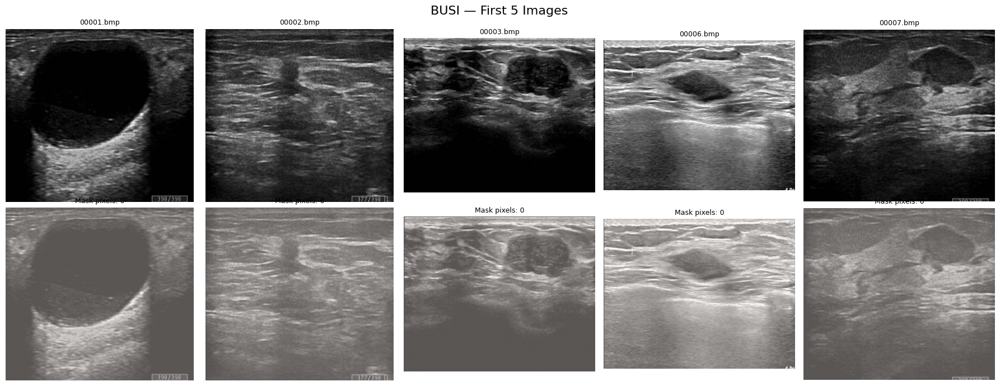


Breast-Lesions-USG
Images found: 252
case001.png: 1 mask(s)
case002.png: 1 mask(s)
case003.png: 1 mask(s)
case004.png: 1 mask(s)
case005.png: 1 mask(s)


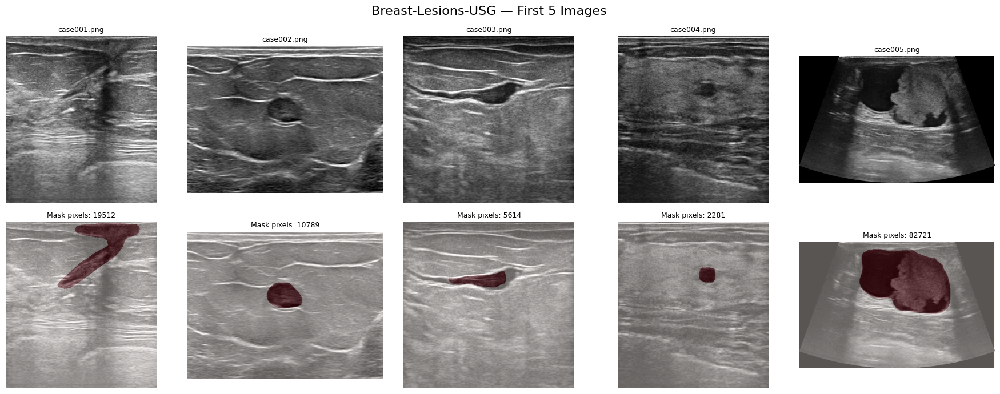


BUS-UCLM
Images found: 683
ALWI_000.png: 1 mask(s)
ALWI_001.png: 1 mask(s)
ALWI_002.png: 1 mask(s)
ALWI_003.png: 1 mask(s)
ALWI_004.png: 1 mask(s)


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# SET YOUR FOUR DATASET PATHS
# ============================================================

DATASETS = {
    "BUSI": r"E:\Research Datasets\Datasets\BUSI",
    "Breast-Lesions-USG": r"E:\Research Datasets\Datasets\BrEaST-Lesions_USG-images_and_masks",
    "BUS-UCLM": r"E:\Research Datasets\Datasets\BUS-UCLM",
    "BUS-BRA": r"E:\Research Datasets\Datasets\BUSBRA",
}


# ============================================================
# IMAGE LOADER
# ============================================================

def load_image(path):
    return np.array(Image.open(path).convert("L"))


# ============================================================
# FIND MASKS FOR AN IMAGE
# ============================================================

def find_masks(mask_dir, image_name):

    stem = os.path.splitext(image_name)[0]

    # Standard cases:
    possible = [
        f"{stem}.png",
        f"{stem}_mask.png",
        f"{stem}_tumor.png",
        f"{stem}_tumor_1.png",
        f"{stem}_tumor_2.png",
        f"{stem}_tumor_3.png",
    ]

    masks = []

    for name in possible:
        path = os.path.join(mask_dir, name)

        if os.path.exists(path):
            masks.append(path)

    # Also catch any additional tumor masks
    for path in glob.glob(
        os.path.join(mask_dir, stem + "_tumor*.png")
    ):
        if path not in masks:
            masks.append(path)

    return masks


# ============================================================
# COMBINE MULTIPLE MASKS
# ============================================================

def load_combined_mask(mask_paths, image_shape):

    combined = np.zeros(image_shape, dtype=np.uint8)

    for path in mask_paths:

        mask = np.array(
            Image.open(path).convert("L")
        )

        # Resize if necessary
        if mask.shape != image_shape:
            mask = np.array(
                Image.fromarray(mask).resize(
                    (image_shape[1], image_shape[0])
                )
            )

        combined[mask > 0] = 1

    return combined


# ============================================================
# GET FIRST 5 IMAGES
# ============================================================

def get_images(image_dir):

    extensions = ["*.png", "*.bmp", "*.jpg", "*.jpeg"]

    files = []

    for ext in extensions:
        files.extend(
            glob.glob(os.path.join(image_dir, ext))
        )

    return sorted(files)


# ============================================================
# VISUALIZE ONE DATASET
# ============================================================

def visualize_dataset(dataset_name, dataset_path):

    image_dir = os.path.join(dataset_path, "images")
    mask_dir = os.path.join(dataset_path, "masks")

    image_files = get_images(image_dir)

    print("\n" + "=" * 60)
    print(dataset_name)
    print("=" * 60)

    print("Images found:", len(image_files))

    if len(image_files) == 0:
        print("WARNING: No images found!")
        return

    selected = image_files[:5]

    fig, axes = plt.subplots(
        2, 5,
        figsize=(18, 7)
    )

    fig.suptitle(
        f"{dataset_name} — First 5 Images",
        fontsize=16
    )

    for i, image_path in enumerate(selected):

        image_name = os.path.basename(image_path)

        image = load_image(image_path)

        mask_paths = find_masks(
            mask_dir,
            image_name
        )

        if len(mask_paths) > 0:

            mask = load_combined_mask(
                mask_paths,
                image.shape
            )

            print(
                f"{image_name}: "
                f"{len(mask_paths)} mask(s)"
            )

        else:

            mask = np.zeros_like(
                image,
                dtype=np.uint8
            )

            print(
                f"{image_name}: NO MASK"
            )

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        axes[0, i].imshow(
            image,
            cmap="gray"
        )

        axes[0, i].set_title(
            image_name,
            fontsize=9
        )

        axes[0, i].axis("off")

        # ----------------------------------------------------
        # IMAGE + MASK
        # ----------------------------------------------------

        axes[1, i].imshow(
            image,
            cmap="gray"
        )

        axes[1, i].imshow(
            mask,
            cmap="Reds",
            alpha=0.35
        )

        axes[1, i].set_title(
            f"Mask pixels: {mask.sum()}",
            fontsize=9
        )

        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN ALL FOUR DATASETS
# ============================================================

for name, path in DATASETS.items():

    visualize_dataset(
        name,
        path
    )